# Постановка задачи

Подготовьте прототип модели машинного обучения для «Цифры». Компания разрабатывает решения для эффективной работы промышленных предприятий.
Модель должна предсказать коэффициент восстановления золота из золотосодержащей руды. В вашем распоряжении данные с параметрами добычи и очистки.
Модель поможет оптимизировать производство, чтобы не запускать предприятие с убыточными характеристиками.
Вам нужно:
1. Подготовить данные;
2. Провести исследовательский анализ данных;
3. Построить и обучить модель.

Чтобы выполнить проект, обращайтесь к библиотекам pandas, matplotlib и sklearn. Вам поможет их документация.
Следующий урок посвящён технологическому процессу очистки руды. Решите сами, какие детали нужны для построения модели, а какие — нет.


Как золото получают из руды? Изучите внимательно стадии процесса.
Когда добытая руда проходит первичную обработку, получается дроблёная смесь. Её отправляют на флотацию (обогащение) и двухэтапную очистку.

Опишем каждую стадию:
1. Флотация
Во флотационную установку подаётся смесь золотосодержащей руды. После обогащения получается черновой концентрат и «отвальные хвосты», то есть остатки продукта с низкой концентрацией ценных металлов.
На стабильность этого процесса влияет непостоянное и неоптимальное физико-химическое состояние флотационной пульпы (смеси твёрдых частиц и жидкости).
2. Очистка
Черновой концентрат проходит две очистки. На выходе получается финальный концентрат и новые отвальные хвосты.

# Описание данных

**Технологический процесс**

- Rougher feed — исходное сырье
- Rougher additions (или reagent additions) — флотационные реагенты: Xanthate, Sulphate, Depressant
- Xanthate **- ксантогенат (промотер, или активатор флотации);
- Sulphate — сульфат (на данном производстве сульфид натрия);
- Depressant — депрессант (силикат натрия).
- Rougher process (англ. «грубый процесс») — флотация
- Rougher tails — отвальные хвосты
- Float banks — флотационная установка
- Cleaner process — очистка
- Rougher Au — черновой концентрат золота
- Final Au — финальный концентрат золота

**Параметры этапов**

- air amount — объём воздуха
- fluid levels — уровень жидкости
- feed size — размер гранул сырья
- feed rate — скорость подачи

**Наименование признаков**

Наименование признаков должно быть такое:
- [этап].[тип_параметра].[название_параметра]
- Пример: rougher.input.feed_ag
Возможные значения для блока [этап]:
- rougher — флотация
- primary_cleaner — первичная очистка
- secondary_cleaner — вторичная очистка
- final — финальные характеристики
Возможные значения для блока [тип_параметра]:
- input — параметры сырья
- output — параметры продукта
- state — параметры, характеризующие текущее состояние этапа
- calculation — расчётные характеристики

# Шаг 1. Подготовка данных

На данном этапе:
1. Откроем файлы и изучим их.
2. Проверим, что эффективность обогащения рассчитана правильно
3. Проанализируем признаки, недоступные в тестовой выборке
4. Проведем предобработку данных.


## Шаг 1.1. Открытие и изучение файлов 

В этом шаге:
- Импортируем библиотеки.
- Откроем файлы с данными
- Изучим файлы с данными

Для начала импортируем все необходимые библиотеки для работы:

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error # абсолютная ошибка 
from sklearn.linear_model import LinearRegression # линейная регрессия
from sklearn.ensemble import RandomForestRegressor # случайный лес
from sklearn.tree import DecisionTreeRegressor # дерево решений
from sklearn.model_selection import train_test_split # деление на 2 выборки
from sklearn.preprocessing import StandardScaler # для масштабирования количественных признаков
from sklearn.model_selection import GridSearchCV # поиск лучших параметров для модели
from sklearn.model_selection import cross_val_score # кросс-валидация
from sklearn.metrics import make_scorer 
pd.set_option('display.max_columns', None) # реализуем возможность вывода всех столбцов на экран
pd.set_option('display.float_format', '{:.3f}'.format) # выводим значения float до 3 знаков после запятой

Откроем файлы с данными и изучим первые 5 строк.

In [2]:
df_train = pd.read_csv('/datasets/gold_recovery_train.csv', sep=',', parse_dates = ['date'])
df_test = pd.read_csv('/datasets/gold_recovery_test.csv', sep=',', parse_dates = ['date'])
df_full = pd.read_csv('/datasets/gold_recovery_full.csv', sep=',', parse_dates = ['date'])

display(df_full.head())
display(df_train.head())
display(df_test.head())

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055,9.890,5.507,42.192,70.541,10.412,0.895,16.904,2.143,127.092,10.128,7.250,0.989,8.548,10.390,19.529,34.174,14.937,2.535,7.476,2.107,1549.776,-498.912,1551.434,-516.403,1549.874,-498.667,1554.367,-493.428,41885.707,3481.779,3520.337,2.839,6.100,2.285,523.546,55.487,36.809,6.486,11.987,6.008,11.837,6.006,11.501,7.101,28.029,19.794,87.108,5.008,0.509,19.154,1.170,999.707,-404.067,1603.011,-434.715,1602.375,-442.204,1598.937,-451.294,1404.472,-455.463,1416.355,-451.940,14.500,4.695,8.765,2.606,25.853,-498.526,23.894,-501.406,23.962,-495.263,21.940,-499.341,14.017,-502.488,12.100,-504.716,9.926,-498.310,8.080,-500.471,14.151,-605.842
1,2016-01-15 01:00:00,6.029,9.969,5.258,42.702,69.266,10.463,0.927,16.635,2.225,125.629,10.296,7.250,1.003,8.559,10.497,19.369,34.119,16.251,3.050,6.734,2.353,1576.167,-500.905,1575.951,-499.866,1575.994,-499.315,1574.479,-498.932,42050.862,3498.371,3489.982,2.859,6.161,2.266,525.291,57.279,35.753,6.479,11.971,6.006,11.996,6.013,11.616,7.279,28.067,20.051,86.843,4.955,0.537,18.965,1.185,1000.286,-400.065,

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055,9.890,5.507,42.192,70.541,10.412,0.895,16.904,2.143,127.092,10.128,7.250,0.989,8.548,10.390,19.529,34.174,14.937,2.535,7.476,2.107,1549.776,-498.912,1551.434,-516.403,1549.874,-498.667,1554.367,-493.428,41885.707,3481.779,3520.337,2.839,6.100,2.285,523.546,55.487,36.809,6.486,11.987,6.008,11.837,6.006,11.501,7.101,28.029,19.794,87.108,5.008,0.509,19.154,1.170,999.707,-404.067,1603.011,-434.715,1602.375,-442.204,1598.937,-451.294,1404.472,-455.463,1416.355,-451.940,14.500,4.695,8.765,2.606,25.853,-498.526,23.894,-501.406,23.962,-495.263,21.940,-499.341,14.017,-502.488,12.100,-504.716,9.926,-498.310,8.080,-500.471,14.151,-605.842
1,2016-01-15 01:00:00,6.029,9.969,5.258,42.702,69.266,10.463,0.927,16.635,2.225,125.629,10.296,7.250,1.003,8.559,10.497,19.369,34.119,16.251,3.050,6.734,2.353,1576.167,-500.905,1575.951,-499.866,1575.994,-499.315,1574.479,-498.932,42050.862,3498.371,3489.982,2.859,6.161,2.266,525.291,57.279,35.753,6.479,11.971,6.006,11.996,6.013,11.616,7.279,28.067,20.051,86.843,4.955,0.537,18.965,1.185,1000.286,-400.065,

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.801,14.993,8.080,1.005,1398.981,-500.226,1399.145,-499.920,1400.103,-500.704,1399.002,-499.485,13.129,5.637,489.794,62.710,42.022,12.084,16.923,6.153,16.868,6.151,1001.849,-350.301,1249.739,-399.108,1249.751,-399.397,1198.288,-399.489,999.472,-399.531,949.566,-398.181,24.938,-500.491,14.948,-500.014,20.018,-450.396,13.987,-449.832,12.024,-497.796,8.017,-501.289,7.947,-432.318,4.873,-500.037,26.706,-499.709
1,2016-09-01 01:59:59,215.392,14.987,8.080,0.990,1398.778,-500.057,1398.055,-499.778,1396.151,-499.240,1399.508,-500.416,13.036,5.526,490.105,61.961,41.188,11.919,17.003,5.999,16.996,6.002,998.691,-350.426,1248.395,-399.946,1249.514,-399.631,1200.506,-399.942,1000.002,-399.492,950.200,-405.788,24.923,-499.814,14.931,-500.764,19.989,-450.114,14.093,-450.059,12.058,-498.696,8.131,-499.634,7.958,-525.840,4.879,-500.162,25.020,-499.819
2,2016-09-01 02:59:59,215.260,12.885,7.787,0.996,1398.494,-500.868,1398.860,-499.765,1398.076,-502.152,1399.497,-499.715,13.138,5.427,489.618,66.904,42.546,12.091,16.993,5.851,16.982,5.854,998.517,-349.784,1247.441,-400.264,1248.207,-401.074,1199.770,-400.791,999.926,-399.237,950.320,-400.864,24.909,-500.304,14.997,-500.994,20.040,-450.263,14.078,-449.661,11.962,-498.767,8.097,-500.827,8.071,-500.802,4.905,-499.829,24.995,-500.623
3,2016-09-01 03:59:59,215.336,12.007,7.640,0.864,1399.618,-498.864,1397.440,-499.211,1400.129,-498.356,1401.065,-501.039,12.401,5.115,476.618,59.866,41.060,12.182,16.532,5.802,16.515,5.804,1000.277,-350.173,1251.323,-398.655,1250.494,-399.747,1199.399,-397.503,1001.931,-400.438,950.735,-399.803,24.894,-499.382,14.917,-499.862,20.031,-449.373,14.014,-449.527,12.033,-498.351,8.075,-499.474,7.897,-500.869,4.931,-499.964,24.949,-498.710
4,2016-09-01 04:59:59,199.099,10.683,7.530,0.806,1401.268,-500.808,1398.129,-499.505,1402.172,-500.811,1399.481,-499.374,11.327,4.767,488.248,63.315,41.269,11.290,13.607,5.738,13.650,5.740,996.541,-350.563,1304.659,-399.512,1306.456,-399.051,1248.699,-400.877,1058.839,-398.988,949.645,-399.278,24.887,-499.357,14.979,-500.187,19.962,-450.639,14.009,-450.022,12.025,-500.786,8.

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>

<font color='green'>СУПЕР!!!!! данные на базе)

Изучим общую информацию о датафреймах.

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                16860 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         16788 non-null  float64       
 2   final.output.concentrate_pb                         16788 non-null  float64       
 3   final.output.concentrate_sol                        16490 non-null  float64       
 4   final.output.concentrate_au                         16789 non-null  float64       
 5   final.output.recovery                               15339 non-null  float64       
 6   final.output.tail_ag                                16794 non-null  float64       
 7   final.output.tail_pb                                16677 non-null  float64       
 8   final.

In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        5856 non-null   datetime64[ns]
 1   primary_cleaner.input.sulfate               5554 non-null   float64       
 2   primary_cleaner.input.depressant            5572 non-null   float64       
 3   primary_cleaner.input.feed_size             5856 non-null   float64       
 4   primary_cleaner.input.xanthate              5690 non-null   float64       
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64       
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64       
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64       
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64       
 9   primary_

In [5]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                22716 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         22627 non-null  float64       
 2   final.output.concentrate_pb                         22629 non-null  float64       
 3   final.output.concentrate_sol                        22331 non-null  float64       
 4   final.output.concentrate_au                         22630 non-null  float64       
 5   final.output.recovery                               20753 non-null  float64       
 6   final.output.tail_ag                                22633 non-null  float64       
 7   final.output.tail_pb                                22516 non-null  float64       
 8   final.

- Датасет df_full содержит 87 столбцов и 22716 строк. В строках есть пропуски. 0 столбец дублирует id, его можно удалить. В первом столбце тип данных - datetime, во всех остальных - float.                                                
- Датасет df_train содержит 87 столбцов и 16859 строк. В строках есть пропуски. 0 столбец дублирует id, его можно удалить. В первом столбце тип данных - datetime, во всех остальных - float.       
- Датасет df_test содержит 53 столбцов и 5856 строк. В строках и столбцах есть пропуски. 0 столбец дублирует id, его можно удалить. В первом столбце тип данных - datetime, во всех остальных - float.       

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>

<font color='green'>таааааак, на месте первичный аналитический осмотр, принято.

## Шаг 1.2. Проверка расчета эффективности обогащения

В этом шаге:
- Проверим, что эффективность обогащения рассчитана правильно.
- Вычислим её на обучающей выборке для признака rougher.output.recovery.
- Найдем MAE между вашими расчётами и значением признака.
- Опишем выводы.

Эффективность обогащения рассчитывается по формуле

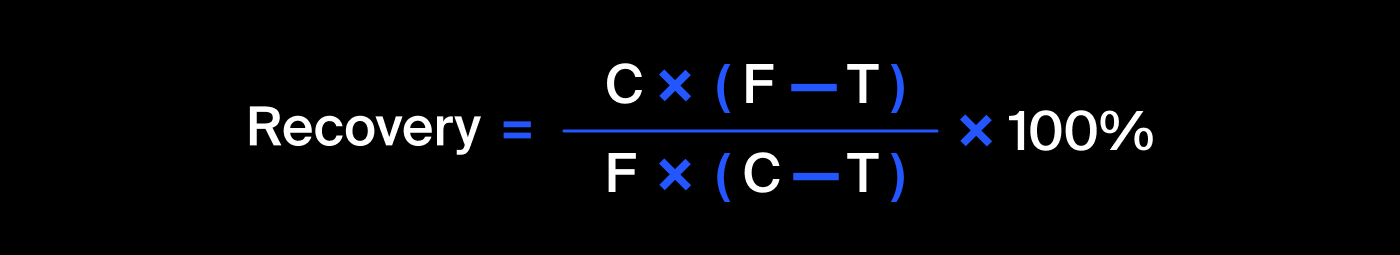

где:

- C — доля золота в концентрате после флотации/очистки;
- F — доля золота в сырье/концентрате до флотации/очистки;
- T — доля золота в отвальных хвостах после флотации/очистки.
- R (Recovery)  — Эффективность обогащения


Обозначим переменные.

In [6]:
C = df_train['rougher.output.concentrate_au']
F = df_train['rougher.input.feed_au']
T = df_train['rougher.output.tail_au']
R = df_train['rougher.output.recovery']

Объединим все данные в одну таблицу.

In [7]:
CFTR  = pd.concat([C, F, T, R], axis=1)

Удалим пропущенные значения из таблицы.

In [8]:
CFTR.dropna(inplace=True)

Проверим полученнную таблицу.

In [9]:
CFTR.head()

,rougher.output.concentrate_au,rougher.input.feed_au,rougher.output.tail_au,rougher.output.recovery
0,19.794,6.486,1.170,87.108
1,20.051,6.479,1.185,86.843
2,19.737,6.362,1.163,86.842
3,19.321,6.118,1.080,87.226
4,19.216,5.664,1.013,86.689


Напишем функцию для расчета эффективности обогащения.

In [10]:
def calc_recovery(C,F,T):
    calc_rougher_output_recovery=((C*(F-T))/(F*(C-T)))*100
    return calc_rougher_output_recovery

Вызовем функцию и передадим ей аргументы, определим ее в отдельную переменную.

In [11]:
calc = calc_recovery(CFTR['rougher.output.concentrate_au'], CFTR['rougher.input.feed_au'], CFTR['rougher.output.tail_au'])

Рассчитаем значение средней абсолютной ошибки (MAE) между нашими расчётами и значением признака.

In [12]:
mae = mean_absolute_error (calc, CFTR['rougher.output.recovery'])
print(mae)

9.303415616264301e-15


Опишем вывод:

Значение MAE стремится к 0,это значит наши расчеты совпадают с признаком rougher.output.recovery. Соответственно считаем, что в дальнейшем данная формула подходит для расчетов

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>

<font color='green'>есть контакт), отлично.

# Шаг 1.3. Анализ признаков, недоступных в тестовой выборке. 

В текущем шаге:
- Проанализируйем признаки, недоступные в тестовой выборке
- Определим, что это за параметры
- Определим, к какому типу относятся 

Посмотрим, есть ли разница в столбцах между датафреймом df_full и df_train.

In [13]:
df_full.columns.difference(df_train.columns)

Index([], dtype='object')

Нет, названия столбцов совпдают.

Посмотрим, каких признаков не хватает в датафрейме df_test.

In [14]:
df_full.columns.difference(df_test.columns)

Index(['final.output.concentrate_ag', 'final.output.concentrate_au',
       'final.output.concentrate_pb', 'final.output.concentrate_sol',
       'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_au',
       'final.output.tail_pb', 'final.output.tail_sol',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.concentrate_sol',
       'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au',
       'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol',
       'rougher.calculation.au_pb_ratio',
       'rougher.calculation.floatbank10_sulfate_to_au_feed',
       'rougher.calculation.floatbank11_sulfate_to_au_feed',
       'rougher.calculation.sulfate_to_au_concentrate',
       'rougher.output.concentrate_ag', 'rougher.output.concentrate_au',
       'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol',
       'roughe

Из полученного списка столбцов видим, что в тестовых данных не хватает тех признаков, которые по техническому процессу не могут быть посчитаны до получения финальных сплавов. Эти признаки также не должны быть использованы при обучении модели. Т.е. перед созданием модели их нужно убрать из обучающей выборки. Исключение составляют два целевых признака - final.output.recovery, rougher.output.recovery.

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА</u>
<font color='green'><br>
В общем, да, 
В тестовой выборке недоступны некоторые расчетные (calculation) и выходные (output) характеристики процесса, т.к. их невозможно получить/измерить во время выполнения технологического процесса. 

# Шаг 1.4. Предобработка данных.

В данном шаге проведем предобработку данных:
- удалим ненужные столбцы
- исключим аномалии
- заполним пропуски 
- добавим целевые признаки в тестовую выборку

Преобразуем список столбцов в список. Удалим из него два целевых признака.

In [15]:
train_columns = df_train.columns.tolist()
train_columns.remove('final.output.recovery')
train_columns.remove('rougher.output.recovery')

Заполним пропуски только по обучающим признакам.

In [16]:
df_full[train_columns] = df_full[train_columns].ffill(axis = 0) 

В качестве индекса сделаем столбцы с датами во всех датасетах:

In [17]:
df_full = df_full.set_index('date')
df_test = df_test.set_index('date')
df_train = df_train.set_index('date')

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>
<font color='green'>дата в индексах, хорошо, Этот подход - самый удобный.

Заполним пропуски методом update в обучающей выборке.

In [18]:
df_train.update(df_full)

Также заполним пропуски методом update в тестовой выборке.

In [19]:
df_test.update(df_full)

Добавляем целевые признаки для тестовой выборки.

In [20]:
df_test['final.output.recovery'] = df_full['final.output.recovery']
df_test['rougher.output.recovery'] = df_full['rougher.output.recovery']
target = ['final.output.recovery', 'rougher.output.recovery']

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>
<font color='green'>и тут отлично. Верно подсоединила тарегт_тест.

Теперь удалим строки с целевыми признаками, значения которых пропущены или равны 0.

In [21]:
target = ['final.output.recovery', 'rougher.output.recovery']

Удалим строки из датафрейма df_full.

In [22]:
df_full = df_full.dropna(subset=target)
df_full = df_full.loc[(df_full['final.output.recovery'] > 0) & (df_full['rougher.output.recovery'] > 0)]

Удалим строки из датафрейма df_train.

In [23]:
df_train = df_train.dropna(subset=target)
df_train = df_train.loc[(df_train['final.output.recovery'] > 0) & (df_train['rougher.output.recovery'] > 0)]

Удалим строки из датафрейма df_test.

In [24]:
df_test = df_test.dropna(subset=target)
df_test = df_test.loc[(df_test['final.output.recovery'] > 0) & (df_test['rougher.output.recovery'] > 0)]

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
</font>
<font color='green'>ок. Чуть ниже оставлю ещё комментарий по нулевым концентрациям

Проверим пропуски во всех датафреймах.

In [25]:
df_full.isna().sum().sum()

0

In [26]:
df_train.isna().sum().sum()

0

In [27]:
df_test.isna().sum().sum()

0

Данные обработаны и готовы к построению модели.

# Шаг 2. Анализ данных

На данном этапе:
- Посмотрим, как меняется концентрация металлов на различных этапах очистки.
- Сравним распределения размеров гранул сырья на обучающей и тестовой выборках.
- Исследуем суммарную концентрацию всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах.

# Шаг 2.1. Анализ концентрации металлов на различных этапах очистки.

Посмотрим, как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки. Сделаем выводы.

Построим распределение для каждого металла в концентрате на разных этапах очистки:

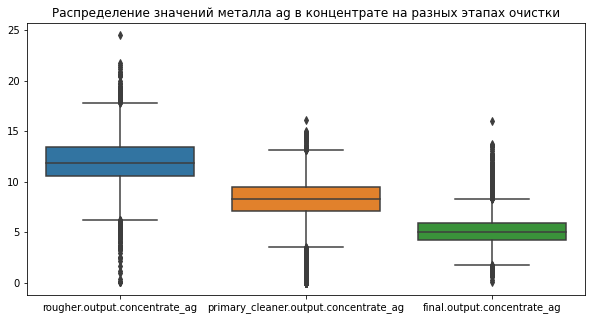

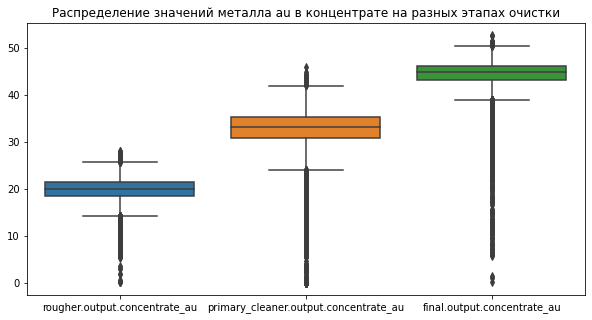

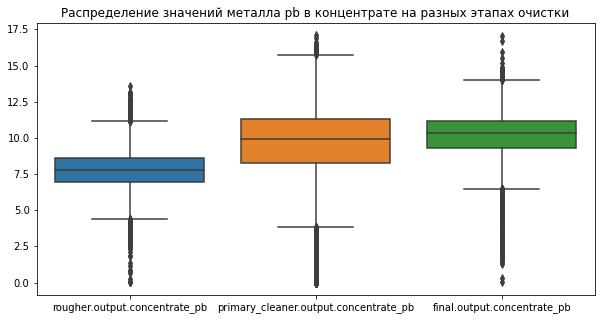

In [28]:
concentrate = {'ag':['rougher.output.concentrate_ag', 'primary_cleaner.output.concentrate_ag', 'final.output.concentrate_ag' ],
               'au':['rougher.output.concentrate_au', 'primary_cleaner.output.concentrate_au', 'final.output.concentrate_au' ],
               'pb':['rougher.output.concentrate_pb', 'primary_cleaner.output.concentrate_pb', 'final.output.concentrate_pb' ]}
#cоздаем словарь с ключами
for key in concentrate: #итеррируем ключи 
    plt.figure(figsize=(10,5))
    sns.boxplot(data = df_train[concentrate[key]])
    plt.title(f'Распределение значений металла {key} в концентрате на разных этапах очистки')
    plt.show()

Построим гистограммы с распределением для каждого металла в концентрате на разных этапах очистки для большей наглядности.

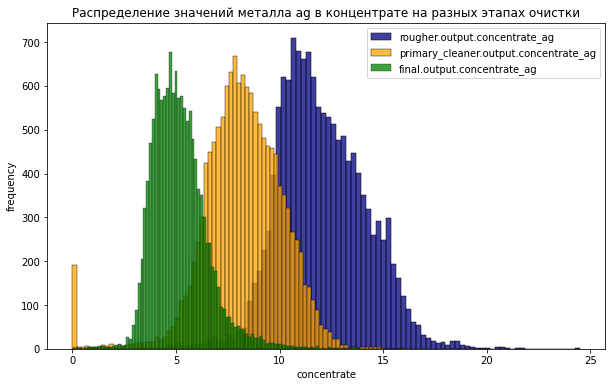

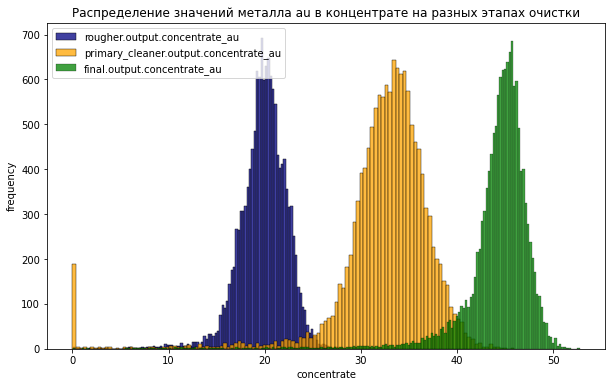

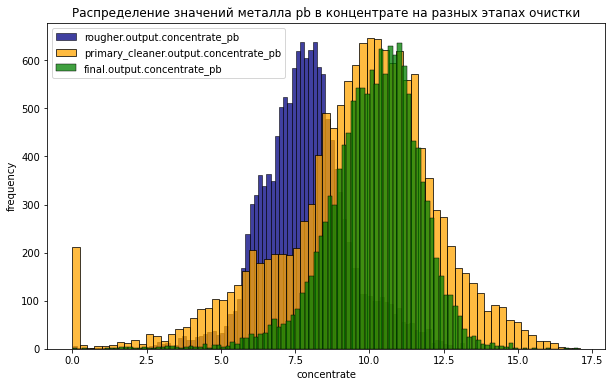

In [29]:
for key in concentrate:
    plt.figure(figsize=(10,6))

    sns.histplot(df_train[concentrate[key][0]],color = 'navy',label=concentrate[key][0])
    sns.histplot(df_train[concentrate[key][1]],color = 'orange',label=concentrate[key][1])
    sns.histplot(df_train[concentrate[key][2]],color = 'green',label=concentrate[key][2])
    plt.xlabel('concentrate')
    plt.ylabel('frequency')
    plt.title(f'Распределение значений металла {key} в концентрате на разных этапах очистки')
    plt.legend()
    plt.show()

Опишем изменения концентраций каждого материала в зависимости от этапа.

**AG** - серебро. Концентрация серебра снижается в процессе обогащения, скорей всего происходит его вымывание из раствора на различных стадиях процесса. На финальном этапе среднее значение концентрации данного материала составляет около 5 %.

**AU** - золото. Концентрация золота закономерно возрастает от начального к конечному этапу - средние значения на финальном этапе находятся в районе 45 %, а это является самой большой величиной в концентрате. 

**PB** - свинец. Концентрация свинца меняется незначительно в процессе обогащения. После первичной очистки значение почти не меняется. На финальном этапе среднее значение концентрации данного материала составляет около 10 %. 


<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА</u>
<font color='green'><br>
КЛАССНО, удобный графический анализ. И ты права, видно, что золотишко растёт - и это хорошо, кому-то). Серебро падает - это логично, мы же производим золоот)<br>
А свинец - побочное дитя химических реакций, поэтому не много увеличивается его содержание)

# Шаг 2.2  Анализ распределения размеров гранул сырья на обучающей и тестовой выборках.

Построим распределения размеров гранул сырья на обучающей и тестовой выборках и сравним их. Если распределения сильно отличаются друг от друга, оценка модели будет неправильной.

Построим распределения размеров гранул сырья на обучающей и тестовой выборках

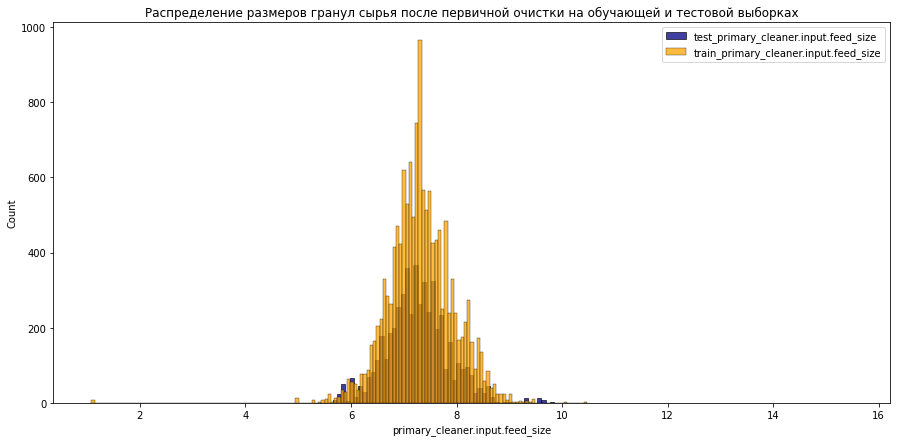

In [30]:
fig = plt.figure(figsize=(15,7))
sns.histplot(df_test['primary_cleaner.input.feed_size'],color = 'navy',label='test_primary_cleaner.input.feed_size')
sns.histplot(df_train['primary_cleaner.input.feed_size'],color = 'orange',label='train_primary_cleaner.input.feed_size')
plt.legend()
plt.title(f'Распределение размеров гранул сырья после первичной очистки на обучающей и тестовой выборках')
plt.show()

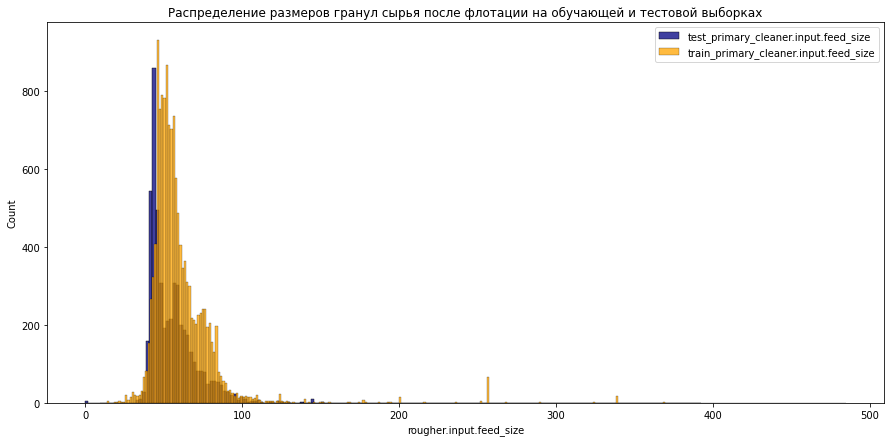

In [31]:
fig = plt.figure(figsize=(15,7))
sns.histplot(df_test['rougher.input.feed_size'],color = 'navy',label='test_primary_cleaner.input.feed_size')
sns.histplot(df_train['rougher.input.feed_size'],color = 'orange',label='train_primary_cleaner.input.feed_size')
plt.title(f'Распределение размеров гранул сырья после флотации на обучающей и тестовой выборках')
plt.legend()
plt.show()

Сравнив гистограммы обучающей и тестовой выборки можно сказать, что распределения размеров гранул сырья не имеют значительных отличий. Можно считать тестовую выборку репрезентативной.

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА</u>
<font color='green'><br>ОК,  верно, распределение для тестовой выборки немного отличается от такового для обучающей - первое сдвинуто немного в меньшую сторону. НО в целом размеры большинства частиц лежат в оптимальном интервале  40—100 мкм  («Флотация руды»: ООО "Техноаналитприбор":[сайт].URL:https://techade.ru/stati/flotatsiya-rudy) для обоих выборок. Поэтому, да, выборки подходят для оценки.

# Шаг 2.3 Анализ суммарной концентрации всех веществ на разных стадиях

Исследуем суммарную концентрацию всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах.

Создадим словарь, в ключи передадим этапы очистки, в значения этапы очистки всех металлов.

In [32]:
sum_concentrate = {'final':['final.output.concentrate_ag', 'final.output.concentrate_au', 'final.output.concentrate_pb',
                           'final.output.concentrate_sol'],
               'rougher':['rougher.output.concentrate_ag', 'rougher.output.concentrate_au', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol'],
               'primary':['primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.concentrate_pb','primary_cleaner.output.concentrate_sol' ]}

Построим распределения с суммарной концентрацией всех веществ на разных стадиях:

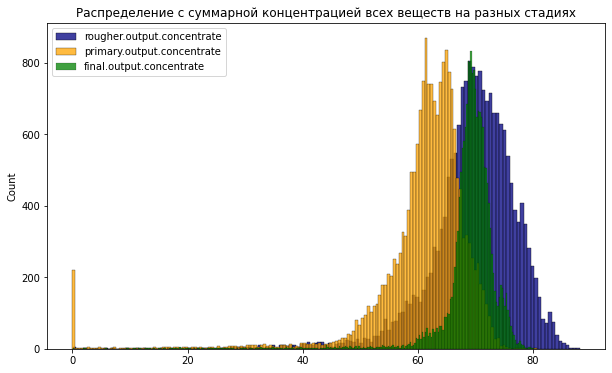

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(sum([df_full[x] for x in sum_concentrate['rougher']]),color = 'navy', label='rougher.output.concentrate')
sns.histplot(sum([df_full[x] for x in sum_concentrate['primary']]),color = 'orange', label='primary.output.concentrate')
sns.histplot(sum([df_full[x] for x in sum_concentrate['final']]),color = 'green', label='final.output.concentrate')
plt.title(f'Распределение с суммарной концентрацией всех веществ на разных стадиях')
plt.legend()
plt.show()

- Суммарная концентрация веществ увеличивается с течением процесса обогащения, что закономерно, т.к. при обработке вымываются лишние примеси и подсадочные реагенты.
- Замечены колебания при нулевых значениях, для первичной очистки это проявляется существенно, для остальных стадий - незначительно. Скорей эти значения получены в те моменты времени когда производственный процесс по каким-либо причинам был остановлен, поэтому такие строки должны быть удалены из датасетов.

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА</u>
<font color='red'><br>
ОК. Тут ещё такой момент с суммарной концентрацией ожидается:<br>
Есть нулевые аномалии в суммарных концентрациях - и их надо "убить". Дело в том, что хоть грамм чего-нибудь но есть в "суммарной руде"- соли+золото+серебро+свинец - точно что-то должно быть.. А если мы имеем ноль, значит большая вероятность неточности измерений.<br>

Общая идея какая с сумарной концентрацией: отдельно по каждой руде нуль может быть (взяли лопату руды - и нет там золота - не всегда же есть крупинки..). А вот нуль суммарно - это уже вряд ли (в этой лопате хоть что-то но будет)

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
    <font color='green'> <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА 2</u></b>
</font>
<font color='green'><br>))

In [52]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18848 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         18848 non-null  float64
 1   final.output.concentrate_pb                         18848 non-null  float64
 2   final.output.concentrate_sol                        18848 non-null  float64
 3   final.output.concentrate_au                         18848 non-null  float64
 4   final.output.recovery                               18848 non-null  float64
 5   final.output.tail_ag                                18848 non-null  float64
 6   final.output.tail_pb                                18848 non-null  float64
 7   final.output.tail_sol                               18848 non-null  float64
 8   final.output.tail_au                     

In [98]:
for key in sum_concentrate:
    sum_0 = df_full[sum_concentrate[key]].sum(axis=1)
    display(df_full[sum_0 == 0]['final.output.concentrate_ag'].count())
    df_full_1 = df_full[sum_0 != 0]
df_full_1.info()

1613

1973

1646

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20992 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                20992 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         20981 non-null  float64       
 2   final.output.concentrate_pb                         20983 non-null  float64       
 3   final.output.concentrate_sol                        20704 non-null  float64       
 4   final.output.concentrate_au                         20984 non-null  float64       
 5   final.output.recovery                               20613 non-null  float64       
 6   final.output.tail_ag                                20987 non-null  float64       
 7   final.output.tail_pb                                20870 non-null  float64       
 8   final.

Обнаружили 101 строку в датафрейме, когда суммарная концентрация равнялась нулю. И удалили их.

In [38]:
for key in sum_concentrate:
    sum_0 = df_train[sum_concentrate[key]].sum(axis=1)
    display(df_train[sum_0 == 0]['final.output.concentrate_ag'].count())
    df_train = df_train[sum_0 != 0]
df_train.info()

0

0

0

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13725 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         13725 non-null  float64
 1   final.output.concentrate_pb                         13725 non-null  float64
 2   final.output.concentrate_sol                        13725 non-null  float64
 3   final.output.concentrate_au                         13725 non-null  float64
 4   final.output.recovery                               13725 non-null  float64
 5   final.output.tail_ag                                13725 non-null  float64
 6   final.output.tail_pb                                13725 non-null  float64
 7   final.output.tail_sol                               13725 non-null  float64
 8   final.output.tail_au                     

Обнаружили 70 строк в датафрейме, когда суммарная концентрация равнялась нулю. И удалили их.

In [90]:
df_full_1=df_full[df_full[sum_concentrate['final']].sum(axis=1)>1]

In [91]:
df_full_2=df_full_1[df_full_1[sum_concentrate['rougher']].sum(axis=1)>1]

In [92]:
df_full_3=df_full_2[df_full_2[sum_concentrate['primary']].sum(axis=1)>1]

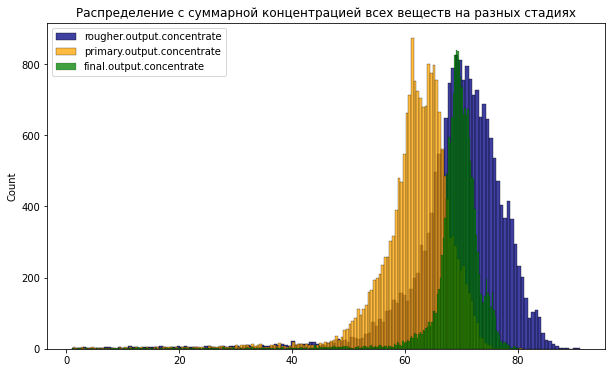

In [99]:
plt.figure(figsize=(10,6))
sns.histplot(sum([df_full_3[x] for x in sum_concentrate['rougher']]),color = 'navy', label='rougher.output.concentrate')
sns.histplot(sum([df_full_3[x] for x in sum_concentrate['primary']]),color = 'orange', label='primary.output.concentrate')
sns.histplot(sum([df_full_3[x] for x in sum_concentrate['final']]),color = 'green', label='final.output.concentrate')
plt.title(f'Распределение с суммарной концентрацией всех веществ на разных стадиях')
plt.legend()
plt.show()

# 3. Построение модели

На текущем этапе:
- Напишем функцию для вычисления итоговой sMAPE.
- Обучим разные модели и оцените их качество кросс-валидацией.
- Выберем лучшую модель и проверим её на тестовой выборке. 
- Опишем выводы.

# 3.1. Функция для вычисления итоговой sMAPE.

Метрика sMAPE вычисляется так:

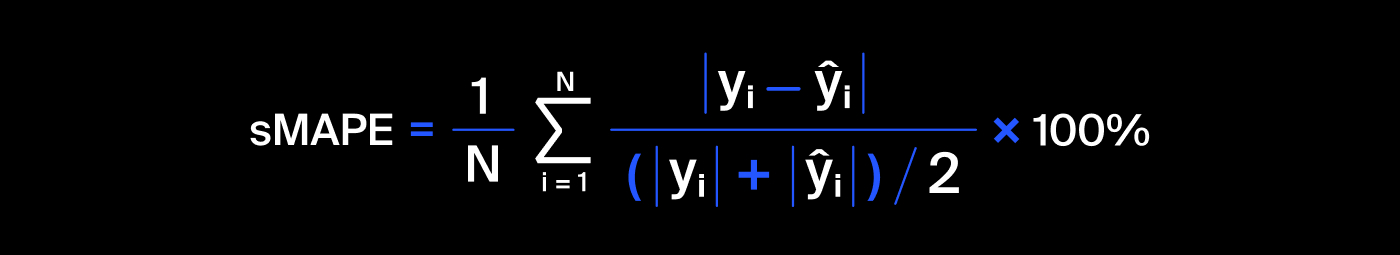

Итоговая метрика складывается из двух величин:

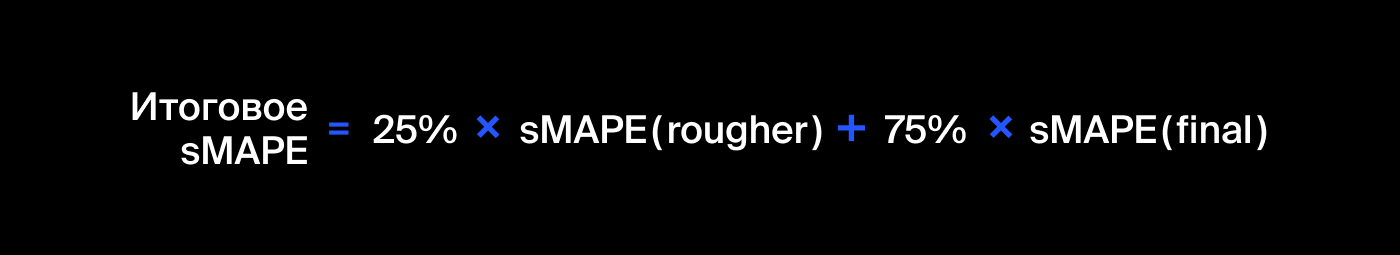

Напишем функцию для вычисления итоговой sMAPE.

In [37]:
def smape (target, predictions):
    numerator = abs(predictions - target)
    denominator = (abs(target) + abs(predictions)) / 2
    summa = (numerator / denominator).sum()
    smape = (1 / len(target)) * summa * 100
    return smape

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА</u>
<font color='green'><br>
ок

# 3.2. Обучение и оценка модели. 

В этом шаге:
- Обучим разные модели и оценим их качество кросс-валидацией. 
- Выберем лучшую модель и проверим её на тестовой выборке.
- Опишем выводы.

Предварительно проведем разделение модели на признаки и их масштабирование.

In [38]:
row_test_columns = df_test.columns
features_rougher = []
for column in row_test_columns:
    if "rougher" in column:
        features_rougher.append(column)

train_features_rougher = df_train[features_rougher]
train_target_rougher = df_train['rougher.output.recovery']
display(train_features_rougher.head())
display(train_target_rougher.head())

,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,rougher.output.recovery
date,,,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.100,2.285,523.546,55.487,36.809,6.486,11.987,6.008,11.837,6.006,999.707,-404.067,1603.011,-434.715,1602.375,-442.204,1598.937,-451.294,1404.472,-455.463,1416.355,-451.940,87.108
2016-01-15 01:00:00,6.161,2.266,525.291,57.279,35.753,6.479,11.971,6.006,11.996,6.013,1000.286,-400.065,1600.755,-449.953,1600.480,-449.831,1600.528,-449.954,1399.227,-450.870,1399.720,-450.119,86.843
2016-01-15 02:00:00,6.116,2.160,530.027,57.511,35.972,6.362,11.921,6.197,11.920,6.205,999.720,-400.074,1599.337,-450.009,1599.673,-449.954,1599.849,-449.954,1399.181,-449.938,1400.317,-450.527,86.842
2016-01-15 03:00:00,6.043,2.038,542.590,57.793,36.862,6.118,11.630,6.203,11.692,6.197,999.815,-400.200,1600.059,-450.620,1600.013,-449.910,1597.725,-450.130,1400.943,-450.030,1400.235,-449.791,87.226
2016-01-15 04:00:00,6.061,1.787,540.532,56.047,34.348,5.664,10.958,6.199,10.961,6.195,999.679,-399.753,1600.209,-449.600,1600.358,-450.034,1599.759,-449.910,1401.561,-448.877,1401.160,-450.407,86.689


date
2016-01-15 00:00:00   87.108
2016-01-15 01:00:00   86.843
2016-01-15 02:00:00   86.842
2016-01-15 03:00:00   87.226
2016-01-15 04:00:00   86.689
Name: rougher.output.recovery, dtype: float64

Подготовим признаки для финального этапа

In [39]:
train_features_final = df_train[df_test.columns].drop(['rougher.output.recovery','final.output.recovery'], axis=1)
train_target_final = df_train['final.output.recovery']
display(train_features_final.head())
display(train_target_final.head())

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,127.092,10.128,7.250,0.989,1549.776,-498.912,1551.434,-516.403,1549.874,-498.667,1554.367,-493.428,6.100,2.285,523.546,55.487,36.809,6.486,11.987,6.008,11.837,6.006,999.707,-404.067,1603.011,-434.715,1602.375,-442.204,1598.937,-451.294,1404.472,-455.463,1416.355,-451.940,25.853,-498.526,23.894,-501.406,23.962,-495.263,21.940,-499.341,14.017,-502.488,12.100,-504.716,9.926,-498.310,8.080,-500.471,14.151,-605.842
2016-01-15 01:00:00,125.629,10.296,7.250,1.003,1576.167,-500.905,1575.951,-499.866,1575.994,-499.315,1574.479,-498.932,6.161,2.266,525.291,57.279,35.753,6.479,11.971,6.006,11.996,6.013,1000.286,-400.065,1600.755,-449.953,1600.480,-449.831,1600.528,-449.954,1399.227,-450.870,1399.720,-450.119,25.881,-499.990,23.890,-500.372,23.971,-500.085,22.086,-499.447,13.992,-505.503,11.951,-501.332,10.039,-500.170,7.985,-500.582,13.998,-599.787
2016-01-15 02:00:00,123.820,11.316,7.250,0.991,1601.556,-499.998,1600.387,-500.608,1602.004,-500.870,1599.542,-499.827,6.116,2.160,530.027,57.511,35.972,6.362,11.921,6.197,11.920,6.205,999.720,-400.074,1599.337,-450.009,1599.673,-449.954,1599.849,-449.954,1399.181,-449.938,1400.317,-450.527,26.005,-499.930,23.887,-499.952,23.914,-499.442,23.958,-499.902,14.015,-502.521,11.913,-501.133,10.071,-500.129,8.014,-500.518,14.029,-601.427
2016-01-15 03:00:00,122.270,11.322,7.250,0.997,1599.969,-500.952,1600.659,-499.677,1600.304,-500.728,1600.450,-500.053,6.043,2.038,542.590,57.793,36.862,6.118,11.630,6.203,11.692,6.197,999.815,-400.200,1600.059,-450.620,1600.013,-449.910,1597.725,-450.130,1400.943,-450.030,1400.235,-449.791,25.943,-499.177,23.956,-499.849,23.967,-500.009,23.954,-499.945,14.037,-500.857,12.000,-501.194,9.970,-499.202,7.977,-500.256,14.006,-599.996
2016-01-15 04:00:00,117.988,11.914,7.250,1.010,1601.340,-498.975,1601.438,-500.323,1599.582,-500.888,1602.650,-500.593,6.061,1.787,540.532,56.047,34.348,5.664,10.958,6.199,10.961,6.195,999.679,-399.753,1600.209,-449.600,1600.358,-450.034,1599.759,-449.910,1401.561,-448.877,1401.160,-450.407,26.025,-500.279,23.955,-500.594,23.986

date
2016-01-15 00:00:00   70.541
2016-01-15 01:00:00   69.266
2016-01-15 02:00:00   68.116
2016-01-15 03:00:00   68.348
2016-01-15 04:00:00   66.927
Name: final.output.recovery, dtype: float64

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
<font color='green'><br>дааа, это нужно было - привести в соответствие трайн и тест.

Подготовим тестовые выборки

In [40]:
test_features_rougher = df_test[features_rougher]
test_target_rougher = df_test['rougher.output.recovery']
test_features_final = df_test.drop(['rougher.output.recovery','final.output.recovery'], axis=1)
test_target_final = df_test['final.output.recovery']

In [41]:
train_features_final.shape

(13725, 52)

Проведем масштабирование признаков этапа флотациим

In [42]:
scaler_rougher = StandardScaler()
scaler_rougher.fit(train_features_rougher)

train_col_rougher = train_features_rougher.columns
test_col_rougher = test_features_rougher.columns

train_features_rougher = scaler_rougher.transform(train_features_rougher)
train_features_rougher = pd.DataFrame(train_features_rougher, columns = train_col_rougher)

test_features_rougher = scaler_rougher.transform(test_features_rougher)
test_features_rougher = pd.DataFrame(test_features_rougher, columns = test_col_rougher)

Проведем масштабирование признаков финального этапа

In [43]:
scaler_final = StandardScaler()
scaler_final.fit(train_features_final)

train_col_final = train_features_final.columns
test_col_final = test_features_final.columns

train_features_final = scaler_final.transform(train_features_final)
train_features_final = pd.DataFrame(train_features_final, columns = train_col_final)

test_features_final = scaler_final.transform(test_features_final)
test_features_final = pd.DataFrame(test_features_final, columns = test_col_final)

Создадим функцию для оценки качества модели с помощью кросс-валидации.

In [44]:
def cross_val (model, features, target):
    scores = cross_val_score(model, features, 
                                   target, scoring=make_scorer(smape, greater_is_better=True), cv=5,n_jobs=-1)
    smape_res = np.mean(scores)
    return smape_res

Создадим функцию для автоматического вывода smape каждого этапа и финальной sMAPE.

In [45]:
def ml(model):
    smape_rougher = cross_val (model, train_features_rougher, train_target_rougher)
    smape_final = cross_val (model, train_features_final, train_target_final)
    smape_end = 0.25 * smape_rougher + 0.75 * smape_final
    print('Средняя оценка качества по кросс-валидации на этапе флотации составила', smape_rougher)
    print('Средняя оценка качества по кросс-валидации на финальном этапе составила', smape_final)
    print('Конечная оценка качества по кросс-валидации составила', smape_end)

Вызовем функцию для модели LinearRegression:

In [46]:
model = LinearRegression()
ml(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 1.8826605334694585e-14
Средняя оценка качества по кросс-валидации на финальном этапе составила 11.039380486446863
Конечная оценка качества по кросс-валидации составила 8.279535364835153


Вызовем функцию для модели DecisionTreeRegressor:

In [47]:
model = DecisionTreeRegressor()
ml(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 0.049640459082548334
Средняя оценка качества по кросс-валидации на финальном этапе составила 16.217546769128404
Конечная оценка качества по кросс-валидации составила 12.17557019161694


Вызовем функцию для модели RandomForestRegressor:

In [48]:
model = RandomForestRegressor()
ml(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 0.04599256946196268
Средняя оценка качества по кросс-валидации на финальном этапе составила 9.72929996209719
Конечная оценка качества по кросс-валидации составила 7.308473113938383


In [49]:
model = DummyRegressor()
ml(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 7.803961504107102
Средняя оценка качества по кросс-валидации на финальном этапе составила 10.412752300489277
Конечная оценка качества по кросс-валидации составила 9.760554601393734


Подготовим функцию для проверки на тесте

In [50]:
def ml_test(model):
    model_rougher = model
    model_rougher.fit(train_features_rougher, train_target_rougher)
    predictions_rougher = model_rougher.predict(test_features_rougher)
    

    model_final = model
    model_rougher.fit(train_features_final, train_target_final)
    predictions_final = model_rougher.predict(test_features_final)
    
    smape_rougher = smape(test_target_rougher, predictions_rougher)
    smape_final = smape(test_target_final, predictions_final)
    smape_end = 0.25 * smape_rougher + 0.75 * smape_final
    print('Средняя оценка качества по кросс-валидации на этапе флотации составила', smape_rougher)
    print('Средняя оценка качества по кросс-валидации на финальном этапе составила', smape_final)
    print('Конечная оценка качества по кросс-валидации составила', smape_end)

In [51]:
model = LinearRegression()
ml_test(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 4.4371550234611026e-15
Средняя оценка качества по кросс-валидации на финальном этапе составила 8.14625379451434
Конечная оценка качества по кросс-валидации составила 6.109690345885756


In [52]:
model = DecisionTreeRegressor()
ml_test(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 0.01800080907314592
Средняя оценка качества по кросс-валидации на финальном этапе составила 13.377631765001688
Конечная оценка качества по кросс-валидации составила 10.037724026019552


In [53]:
model = RandomForestRegressor()
ml_test(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 0.014705955279149105
Средняя оценка качества по кросс-валидации на финальном этапе составила 8.321063461968176
Конечная оценка качества по кросс-валидации составила 6.244474085295919


На тестовой выборке также случайный лес имеет наилучшую среднюю оценку качества.

In [54]:
model = DummyRegressor()
ml_test(model)

Средняя оценка качества по кросс-валидации на этапе флотации составила 5.376429943669653
Средняя оценка качества по кросс-валидации на финальном этапе составила 8.574994488114452
Конечная оценка качества по кросс-валидации составила 7.775353352003252


<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА 2</u></b>
<font color='green'><br>
ОК, Ксения, увидел доработку по константой. <br>
ОК. И видно, что разница средних метрик - совсем не большая. Но тут сложно говорить кто лучше/хуже ...По идее, если хотим точно выяснить - надо испрользовать проверку гипотез мз спринта 4, т.е. сраниваем средние с учётом разброса данных)
Такой "разбег" метрик - допустимо в этом проекте. Что же тогда ещё для дальнейшего улучшения качества моделирования возможно сделать?<br> 
    
Попробовал систематизировать:<br>
1) качество данных на входе: ещё раз оценить аномалии, пропуски, соответствие физике (правдиво ли всё)<br>
2) Работа с моделями:<br>
- Генерация и поиск бизнес-факторов для моделирования: возможно что-то упустили, или придумать что-то гибридное из имеющихся факторов... В общем ещё раз пройтись по бизнес-цепочке процесса<br>
- Подбор самих моделей. показателей самих моделей <br>
- Подбор параметров выбранных показателей у выбранных моделей <br>
    
3)Плюс, есть же ещё параметры самого процесса: температура, скорость конвейера, сила удара чего-то там....<br> Они тоже могут помочь<br>
4) ну и разобраться ещё раз с физическими и производственными процессами. ВОзможно приниципиально иное решение можно создать.<br> 
    
В общем-то другого и нет. Только такие возможности.<br>
Если углубится в так называемый "Статистический анализ данных" (SPC) - по сути это превариетльная подготовка данных в этом проекте, можно найти какое-нибудь решение<br>

Но цель проекта достигнута:<br>
1) пройдены важные этапы построения производственной модели<br>
2) возникло много дополнительных вопросов))<br><br>
   
По коду с отсечкой  0-суммарной концентрации: оставил код раздельный. В цикле - не получится)<br>

Спасибо за работу) УСПЕШНОГО ДАЛЬНЕЙШЕГО ОБУЧЕНИЯ!

# Вывод:

В результате проектной работы: 
1. Подготовили данные
- Открыли файлы и изучите их.
- Проверили, что эффективность обогащения рассчитана правильно. Найшли MAE между расчётами и значением признака.
- Проанализировали признаки, недоступные в тестовой выборке. 
-  Провели предобработку данных.
2. Проанализировали данные
-  Посмотрели, как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки. 
-  Сравнили распределения размеров гранул сырья на обучающей и тестовой выборках. 
- Исследовали суммарную концентрацию всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах.
3. Построили модель
- Написали функцию для вычисления итоговой sMAPE.
- Обучили разные модели и оцените их качество кросс-валидацией. 
- Выбрали лучшую модель и проверьте её на тестовой выборке.
- Определили, что случайный лес имеет наилучшую среднюю оценку качества.

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
    <b><u>КОММЕНТАРИЙ РЕВЬЮЕРА</u></b>
<font color='green'><br>
ОК, Ксения, интересную работу ты провела.<br>
Понятно, логично, вдумчиво<br>
Видна хорошая предвариателная работа с данными, уместный графический анализ, осмысленная аналитика и дельная модельная работа - многое удалось как надо)<br>
    
Метрика - достаточно низкая. И это хорошо.<br>
вот только не понятно насколько))<br>
По хорошему, здесь надо понять: наша модель предсказывает лучше, чем просто по среднему.<br>
Например, в формулу метрики предиктом подставить медианные значения таргет-трайна). <br>
Или использовать DummyRegression (например, как ниже))<br>
<font color='red'>
Покажи, пожалуйста, сравнение и вывод относительно константной модели)
<font color='green'>    
Спасибо)<br>
БУДУ ЖДАТЬ КОММЕНТАРИЕВ!

dummy_regressor_rougher = DummyRegressor(strategy="median")

dummy_regressor_rougher.fit(X_train, y_train_rougher)

dummy_rougher_pred = dummy_regressor_rougher.predict(X_test)

smape_dummy_rougher = smape(y_test_rougher, dummy_rougher_pred)

print(smape_dummy_rougher) 

И ДАЛЕЕ: ДЛЯ FINAL И ИТОГОВЫЙ

In [59]:
random_state = 123
cv = 5
models = [DecisionTreeRegressor(random_state = random_state),  
          LinearRegression(),  DummyRegressor()]


results_cross_val = []

for model in models: 
    
    scorer = make_scorer(smape, greater_is_better=False) 
    
    cross_val_score_rougher = cross_val_score(model, 
                                              train_features_rougher, 
                                              train_target_rougher, 
                                              cv=cv, scoring=scorer).mean()
    cross_val_score_final = cross_val_score(model, 
                                            train_features_final, 
                                            train_target_final, 
                                            cv=cv, scoring=scorer).mean()
    cross_val_score_end = 0.25 * cross_val_score_rougher + 0.75 * cross_val_score_final

    results_cross_val.append({'model name': model.__class__.__name__, 
                              'cross_val_score_rougher': cross_val_score_rougher, 
                              'cross_val_score_final': cross_val_score_final, 
                              'cross_val_score_end': cross_val_score_end})
              
pd.DataFrame(results_cross_val)

,model name,cross_val_score_rougher,cross_val_score_final,cross_val_score_end
0,DecisionTreeRegressor,-0.053,-15.715,-11.799
1,LinearRegression,-0.000,-11.039,-8.280
2,DummyRegressor,-7.804,-10.413,-9.761


<div style="background: #7FC7FF; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='navy'> 
    <b><u>КОММЕНТАРИЙ CТУДЕНТА</u></b>
</font>

<font color='navy'> так? а почему значения с минусом? И модель RandomForestRegressor долго грузится, как ее можно ускорить?

<div style="background: #cceeaa; padding: 5px; border: 1px solid green; border-radius: 5px;">
<font color='green'> 
<u>КОММЕНТАРИЙ РЕВЬЮЕРА 2</u>
<font color='green'><br>В make_scorer параметр greater_is_better=False - он отвечает за то, какая оптимизация происходит. если False, то мы говорит "больше_лучше"=ложь. Т.е. для нас лучше мимнимfмальная ошибка. Поэтому, внутри зашит механизм, который это делает и в итоге вводит минус. От него можно абстрагироваться или умножить на -1 результат.<br>
Через параметры однозначно. Но тут надо сомтреть индивидуально)